<a href="https://colab.research.google.com/github/danielgil2026/c-digoprueba/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [2]:
# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos

import yfinance as yf

In [5]:
activos = ["PEP","EOG","CRM"]

datos = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

# Mostramos las primeras 5 filas para validar la descarga de forma limpia
display(datos.head())

[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker             CRM         EOG         PEP         CRM         EOG   
Date                                                                     
2024-01-02  251.332031  111.429070  156.347321  255.679039  112.986881   
2024-01-03  247.122375  114.526352  156.383469  249.398923  114.947875   
2024-01-04  246.533615  110.897583  155.045227  247.907383  115.525191   
2024-01-05  246.415863  110.311104  152.757568  249.153607  111.850585   
2024-01-08  255.983231  107.919403  152.911285  256.660308  108.285947   

Price                          Low                                Open  \
Ticker             PEP         CRM         EOG         PEP         CRM   
Date                                                                     
2024-01-02  156.419659  249.016240  111.117511  152.983650  255.659424   
2024-01-03  158.417946  247.053695  111.090012  156.157416  248.751283   
2024-01-04  156.907901  245.159832  110.732638  154.240479  247.112559   
2024-01-05  155.135650  245.483662  109.532201  151.509751  246.504188   
2024-01-08  153.471892  246.680820  106.352433  151.717719  247.485466   

Price                                Volume                    
Ticker             EOG         PEP      CRM      EOG      PEP  
Date                                                           
2024-01-02  111.621504  153.282042  4741400  3023000  5743100  
2024-01-03  111.456549  158.237106  5097100  2794000  5588200  
2024-01-04  115.057847  155.171816  4489800  2847500  6283200  
2024-01-05  111.658150  155.135650  3676000  2157100  5252500  
2024-01-08  108.285947  152.757571  6626000  4244600  5735600

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

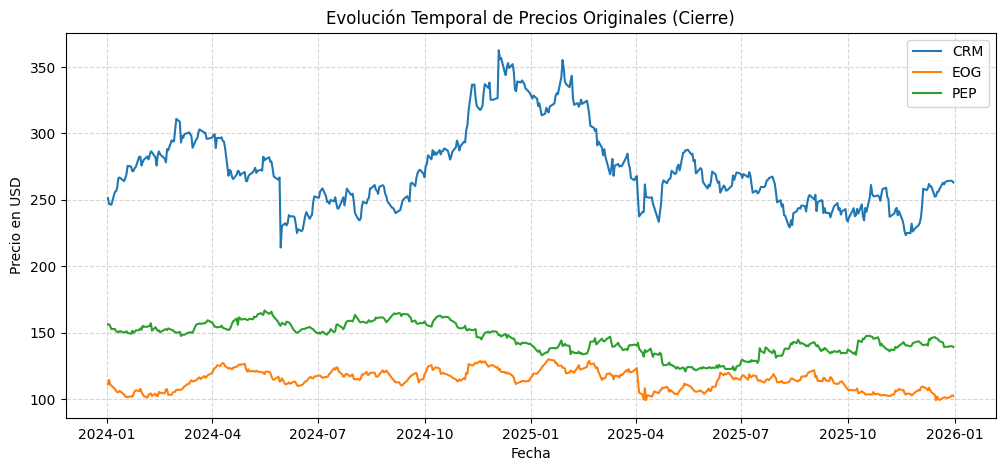

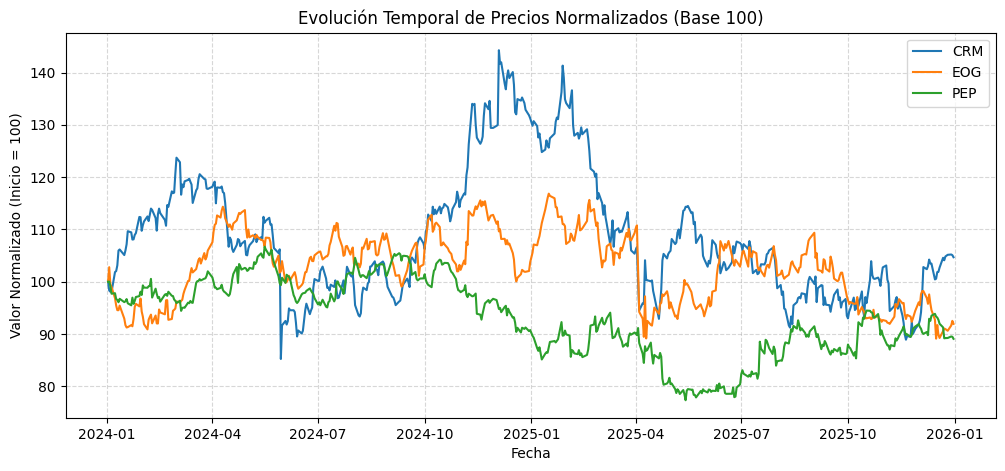

<Axes: >

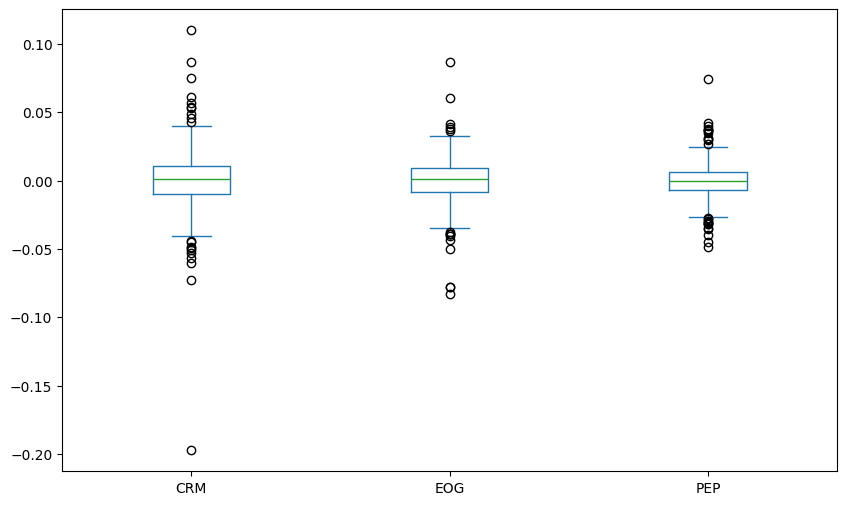

In [9]:
import matplotlib.pyplot as plt

# 1. Extraer los precios de cierre
precios = datos["Close"]

# Calcular normalización en base 100
base100 = precios / precios.iloc[0] * 100

# 2. Graficar precios originales
plt.figure(figsize=(12, 5))
plt.plot(precios)
plt.title("Evolución Temporal de Precios Originales (Cierre)")
plt.xlabel("Fecha")
plt.ylabel("Precio en USD")
plt.legend(precios.columns)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 3. Normalizar y graficar en base 100
plt.figure(figsize=(12, 5))
plt.plot(base100)
plt.title("Evolución Temporal de Precios Normalizados (Base 100)")
plt.xlabel("Fecha")
plt.ylabel("Valor Normalizado (Inicio = 100)")
plt.legend(base100.columns)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

rendimientos.plot.box(figsize=(10,6))

Porque elimina la brecha de los precios nominales (las escalas de cotización en dólares). Al garantizar que todos los activos inicien en un valor común de 100, se compara directamente el rendimiento porcentual acumulado y el crecimiento de la inversión, sin importar si una acción cuesta $100,  $200  o $250.

Precios originales: Las curvas aparecen separadas y dispersas en la grafica; simplemente por su valor nominal, imposibilitando ver con claridad quién ganó o perdió más proporcionalmente.
Precios normalizados: Todas las curvas parten del mismo origen (100), revelando inmediatamente qué activo lideró el rendimiento y cuál obtuvo el peor desempeño acumulado en el periodo analizado.
Por ejemplo, para el periodo 2024-10 al 2025-4 el activo CRM obtubo el mejor rendimiento seguido de EOGy por ultimo PEP.

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?

R/ El activo que presenta mas dispersión es CRM, tambien tiene la mayor desviación estandar 2.14%. Lo que nos dice que es un potencial de mayores ganancias pero tambien de mayores perdidas.
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

R/ Si. En todos los activos se logran evidenciar outliers, representan procesos de variaciones extremas en el precio causadas por eventos específicos de alto impacto (noticias macroeconómicas, reportes trimestrales de ganancias que superaron o decepcionaron las expectativas del mercado o cambios drásticos en los precios de los productos básicos como el petróleo para el caso de EOG).

Desviación Estándar de los Rendimientos (Volatilidad):
Ticker
CRM    0.021398
EOG    0.016259
PEP    0.012438
dtype: float64

El activo más volátil es: CRM



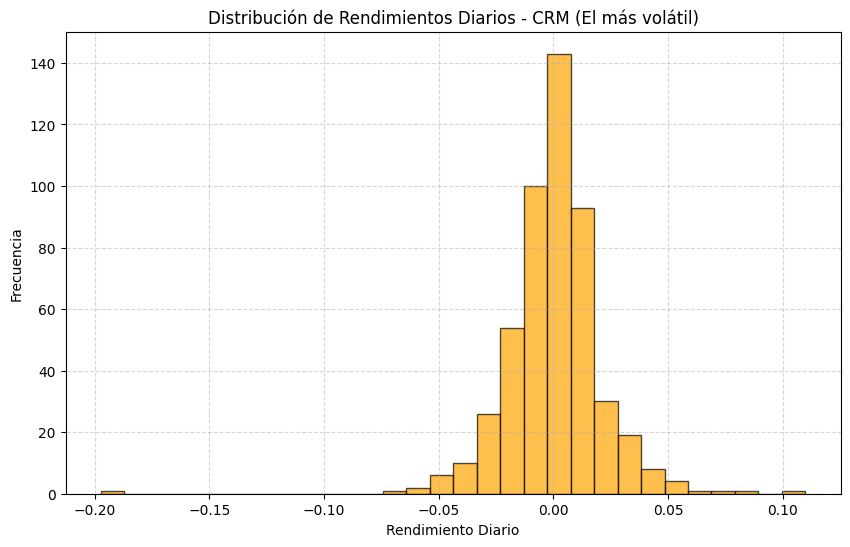

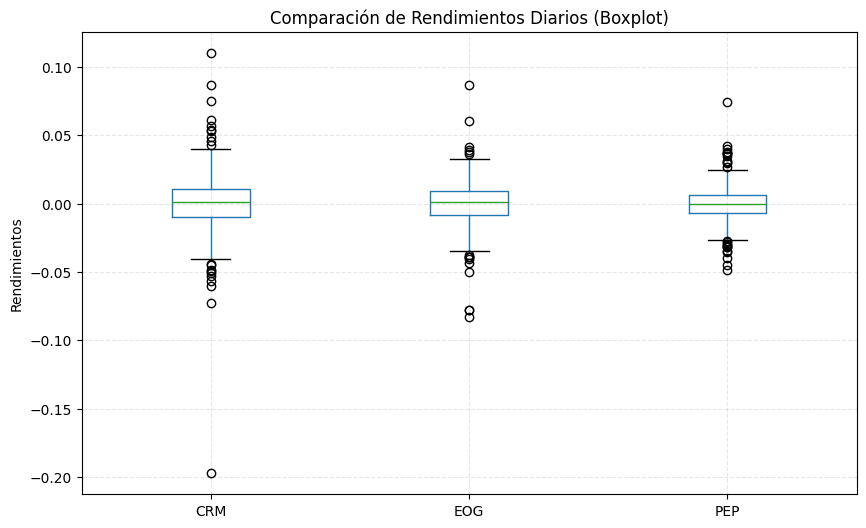

In [17]:
import matplotlib.pyplot as plt

# 1. Calcular rendimientos diarios y eliminar nulos
rendimientos = precios.pct_change().dropna()

# Identificar el activo más volátil (el de mayor desviación estándar)
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()

print("Desviación Estándar de los Rendimientos (Volatilidad):")
print(volatilidad)
print(f"\nEl activo más volátil es: {activo_mas_volatil}\n")

# 2. Histograma con el activo más volátil
plt.figure(figsize=(10, 6))
plt.hist(rendimientos[activo_mas_volatil], bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.title(f"Distribución de Rendimientos Diarios - {activo_mas_volatil} (El más volátil)")
plt.xlabel("Rendimiento Diario")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 3. Boxplot comparativo de rendimientos de los 3 activos simultáneamente
plt.figure(figsize=(10, 6))
rendimientos.boxplot()
plt.title("Comparación de Rendimientos Diarios (Boxplot)")
plt.ylabel("Rendimientos")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?

R/ No, todas las correlaciones son menores a 0.2 y la mayor es de aproximadamente 0.1960 que es la de EOG-CRM

- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

R/ A partir de la matriz de correlación, elegiría CRM y PEP porque tienen la correlación más baja (0.0356), prácticamente cero. Esto maximiza la diversificación porque sus rendimientos diarios se mueven de forma casi totalmente independiente.

Matriz de correlación de Pearson:


Ticker,CRM,EOG,PEP
Ticker,,,
CRM,1.000000,0.196034,0.035615
EOG,0.196034,1.000000,0.093999
PEP,0.035615,0.093999,1.000000


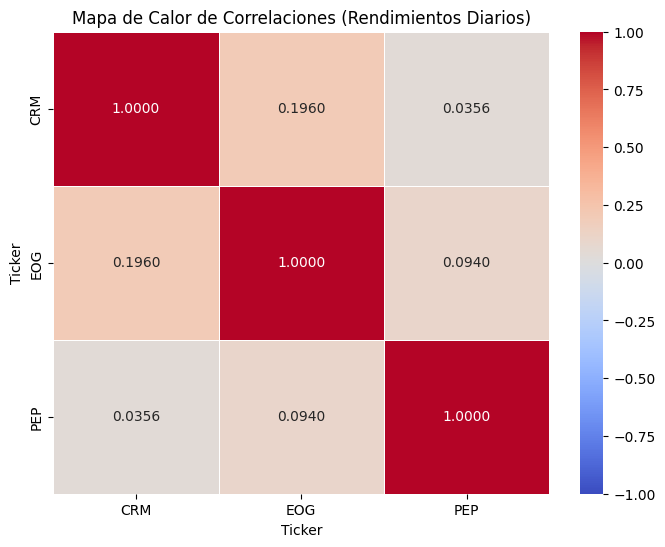

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular matriz de correlación de Pearson
correlacion = rendimientos.corr(method='pearson')

print("Matriz de correlación de Pearson:")
display(correlacion)

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".4f",
    linewidths=0.5
)
plt.title("Mapa de Calor de Correlaciones (Rendimientos Diarios)")
plt.show()

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

CRM es el único con rendimiento promedio positivo diario (+0.03%) pero su volatilidad es la más alta (2.14%) y ha tenido caídas de hasta un -19.7%. Por lo tanto seria una excelente posibilidad de ganancias fuertes si se puede aguantar el riesgo, este es tu activo.

PEP (PepsiCo): Aunque su rendimiento promedio estuvo plano, es por mucho el más estable (volatilidad de solo 1.24%) y sus peores caídas no pasaron del -4.8%. Ideal para mantener el barco a flote cuando el mercado se pone feo.

EOG Resources: El punto medio inestable. Está muy amarrado a los precios del petróleo. Su volatilidad es intermedia (1.62%), pero cerró el periodo con un promedio diario ligeramente negativo.

Con este panorama, poner todo el dinaero en un solo activo seria muy riesgoso, se podria diversificar así: como CRM y PEP casi no se correlacionan (0.03) mientras que CRM busque las ganancias, PEP amortigua los golpes y asegura la inversión.

In [22]:
import pandas as pd

# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
resumen_estadistico = pd.DataFrame({
    'Media (Daily Mean)': rendimientos.mean(),
    'Mediana (Daily Median)': rendimientos.median(),
    'Desviación Estándar (Std Dev)': rendimientos.std(),
    'Mínimo (Min)': rendimientos.min(),
    'Máximo (Max)': rendimientos.max()
}).T

print("=== RESUMEN ESTADÍSTICO DE RENDIMIENTOS DIARIOS ===")
display(resumen_estadistico)

=== RESUMEN ESTADÍSTICO DE RENDIMIENTOS DIARIOS ===


Ticker,CRM,EOG,PEP
Media (Daily Mean),0.000325,-0.000035,-0.000154
Mediana (Daily Median),0.001296,0.000866,-0.000538
Desviación Estándar (Std Dev),0.021398,0.016259,0.012438
Mínimo (Min),-0.197371,-0.082771,-0.048854
Máximo (Max),0.109948,0.086604,0.074547
